# Tree Ensembles: Single Trees to XGBoost

**Duration:** 2 hours
**Goal:** Build ML models from decision trees to XGBoost

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

In [2]:
# Load data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
print(f'Dataset: {X.shape}')

# Split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)
print(f'Train:{len(X_train)} Val:{len(X_val)} Test:{len(X_test)}')

Dataset: (569, 30)
Train:397 Val:86 Test:86


## Part 1: Single Decision Tree

In [ ]:
# Train unlimited tree
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

train_acc = accuracy_score(y_train, tree.predict(X_train))
val_acc = accuracy_score(y_val, tree.predict(X_val))

print(f'Train Acc: {train_acc:.4f}')   # Difference in training and validation accuracy is overfitting
print(f'Val Acc: {val_acc:.4f}')
print(f'Gap: {train_acc - val_acc:.4f} (OVERFITTING!)')
print(f'Depth: {tree.get_depth()}')

Train Acc: 1.0000
Val Acc: 0.9070
Gap: 0.0930 (OVERFITTING!)
Depth: 7


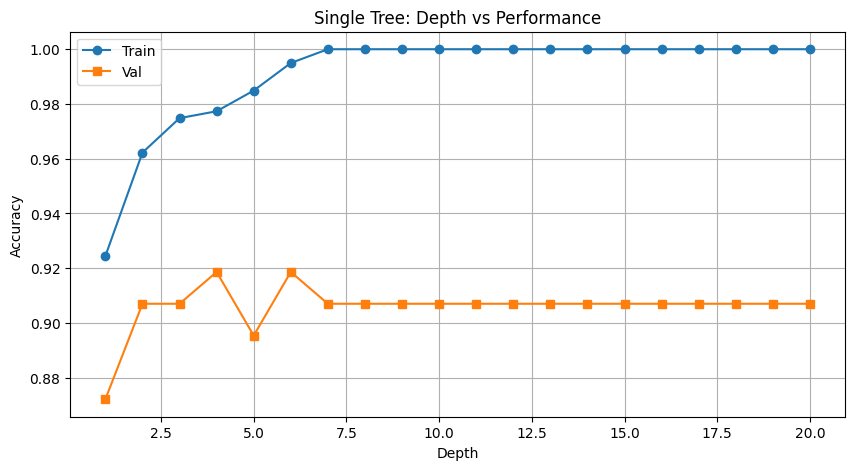

In [ ]:
# Test depths 1-20
depths = range(1, 21)
train_scores = []
val_scores = []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, t.predict(X_train)))
    val_scores.append(accuracy_score(y_val, t.predict(X_val)))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, 'o-', label='Train')
plt.plot(depths, val_scores, 's-', label='Val')
plt.xlabel('Depth'); plt.ylabel('Accuracy')
plt.title('Single Tree: Depth vs Performance')
plt.legend(); plt.grid(); plt.show()

## Part 2: Random Forest

In [ ]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_val_acc = accuracy_score(y_val, rf.predict(X_val))

print(f'Random Forest Val Acc: {rf_val_acc:.4f}')
print(f'Single Tree Val Acc: {val_acc:.4f}')
print(f'Improvement: {rf_val_acc - val_acc:.4f} (+{((rf_val_acc-val_acc)/val_acc*100):.1f}%)')

Random Forest Val Acc: 0.9419
Single Tree Val Acc: 0.9070
Improvement: 0.0349 (+3.8%)


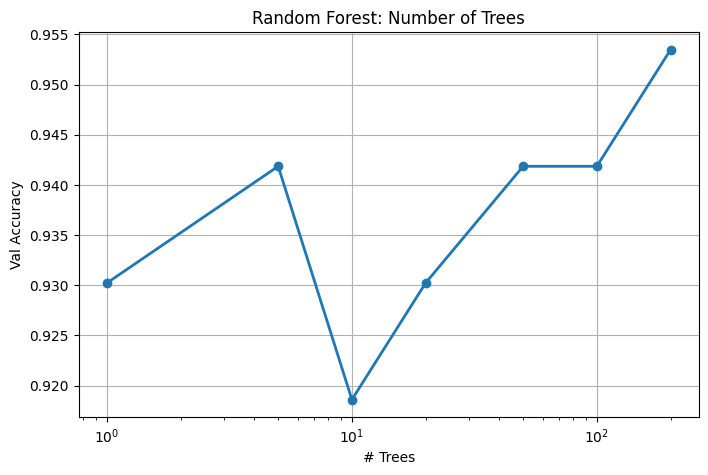

In [ ]:
# Number of trees effect
n_trees = [1, 5, 10, 20, 50, 100, 200]
val_accs = []

for n in n_trees:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1).fit(X_train, y_train)
    val_accs.append(accuracy_score(y_val, rf_temp.predict(X_val)))

plt.figure(figsize=(8, 5))
plt.plot(n_trees, val_accs, 'o-', linewidth=2)
plt.xlabel('# Trees'); plt.ylabel('Val Accuracy')
plt.title('Random Forest: Number of Trees')
plt.xscale('log'); plt.grid(); plt.show()

## Part 3: XGBoost

In [ ]:
# Train XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

xgb_val_acc = accuracy_score(y_val, xgb_model.predict(X_val))
xgb_test_acc = accuracy_score(y_test, xgb_model.predict(X_test))

print(f'XGBoost Val Acc: {xgb_val_acc:.4f}')
print(f'XGBoost Test Acc: {xgb_test_acc:.4f}')

XGBoost Val Acc: 0.9302
XGBoost Test Acc: 0.9419


In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

# Early stopping
xgb_early = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    early_stopping_rounds=20
)

xgb_early.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f'Best iteration: {xgb_early.best_iteration}')
print(f'Best val acc: {accuracy_score(y_val, xgb_early.predict(X_val)):.4f}')

Best iteration: 187
Best val acc: 0.9419


## Part 4: Feature Importance

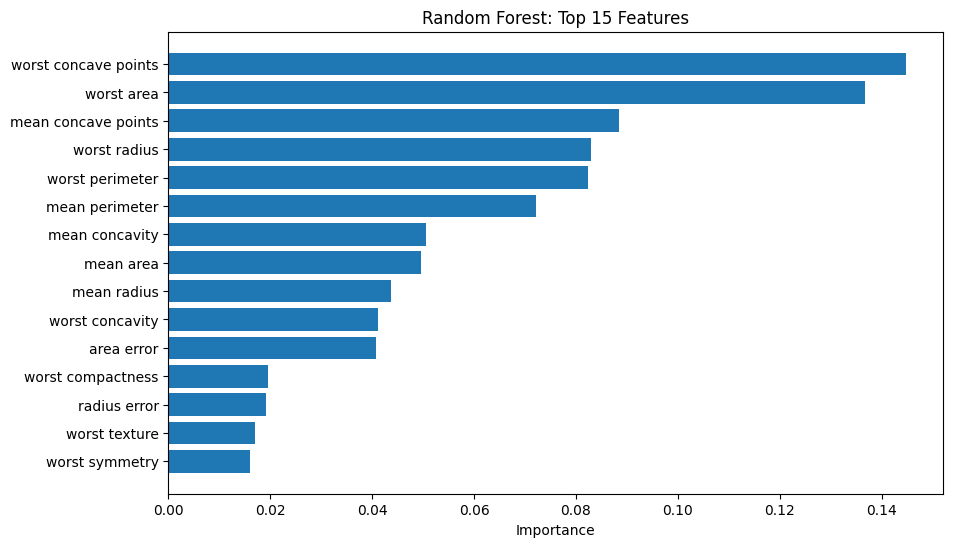

                 feature  importance
27  worst concave points    0.144853
23            worst area    0.136673
7    mean concave points    0.088413
20          worst radius    0.082928
22       worst perimeter    0.082357
2         mean perimeter    0.072218
6         mean concavity    0.050612
3              mean area    0.049631
0            mean radius    0.043638
26       worst concavity    0.041088


In [ ]:
# Random Forest importance
rf_imp = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(range(15), rf_imp.head(15)['importance'])
plt.yticks(range(15), rf_imp.head(15)['feature'])
plt.xlabel('Importance')
plt.title('Random Forest: Top 15 Features')
plt.gca().invert_yaxis()
plt.show()

print(rf_imp.head(10))

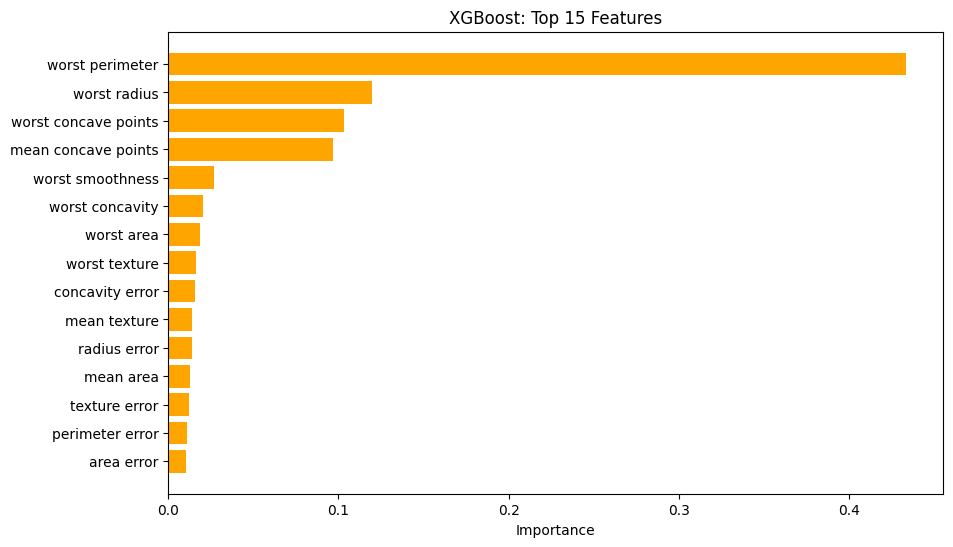

                 feature  importance
22       worst perimeter    0.433859
20          worst radius    0.119773
27  worst concave points    0.103434
7    mean concave points    0.096939
24      worst smoothness    0.026706
26       worst concavity    0.020270
23            worst area    0.018436
21         worst texture    0.016518
16       concavity error    0.015873
1           mean texture    0.014157


In [ ]:
# XGBoost importance
xgb_imp = pd.DataFrame({'feature': X.columns, 'importance': xgb_model.feature_importances_}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(range(15), xgb_imp.head(15)['importance'], color='orange')
plt.yticks(range(15), xgb_imp.head(15)['feature'])
plt.xlabel('Importance')
plt.title('XGBoost: Top 15 Features')
plt.gca().invert_yaxis()
plt.show()

print(xgb_imp.head(10))

## Part 5: Final Comparison

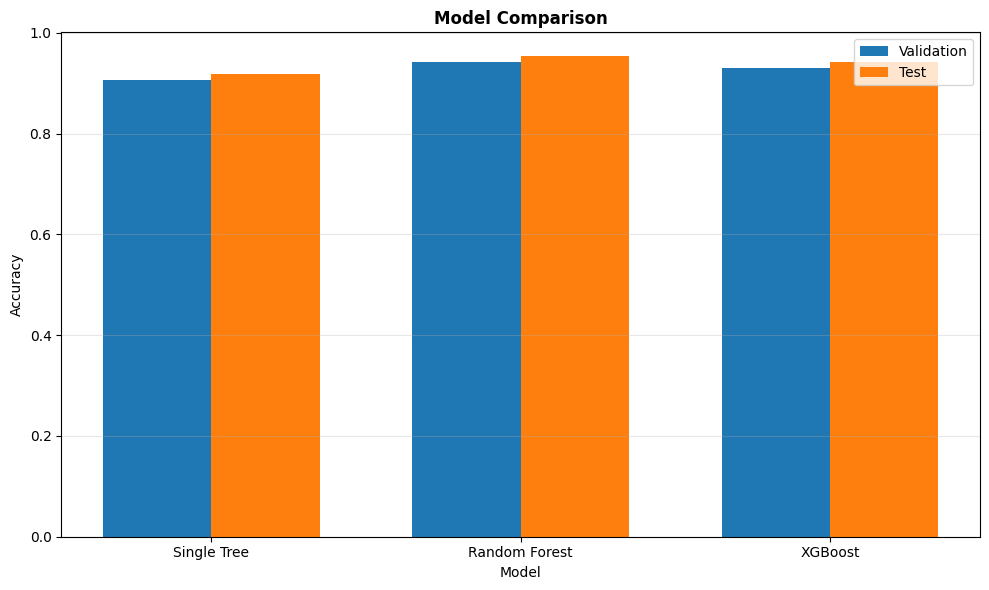


Final Results:
Single Tree     Val:0.9070 Test:0.9186
Random Forest   Val:0.9419 Test:0.9535
XGBoost         Val:0.9302 Test:0.9419


In [ ]:
# Compare all models
models = ['Single Tree', 'Random Forest', 'XGBoost']
val_accuracies = [val_acc, rf_val_acc, xgb_val_acc]
test_accuracies = [
    accuracy_score(y_test, tree.predict(X_test)),
    accuracy_score(y_test, rf.predict(X_test)),
    xgb_test_acc
]

x = range(len(models))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], val_accuracies, width, label='Validation')
plt.bar([i + width/2 for i in x], test_accuracies, width, label='Test')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Comparison', fontweight='bold')
plt.xticks(x, models)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nFinal Results:')
for i, model in enumerate(models):
    print(f'{model:15} Val:{val_accuracies[i]:.4f} Test:{test_accuracies[i]:.4f}')

## Summary

**Key Learnings:**
1. Single trees overfit easily
2. Random Forest reduces variance through bagging
3. XGBoost uses boosting for best performance
4. Feature importance helps interpretation

**Next Steps:** Try these models on your own datasets!